# 📊 Análise de Churn — Por que clientes abandonam um app?

**Objetivo:** Identificar o perfil de clientes que cancelam a assinatura de um app, usando dados e visualizações para apoiar decisões de produto.

**Ferramentas:** Python, Pandas, Seaborn, Matplotlib, SQL

**Autor:** [Yasmin Guedes]

In [ ]:
# Importando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Criando a base de dados com 300 clientes
np.random.seed(42)

df = pd.DataFrame({
    "cliente_id": range(1, 301),
    "idade": np.random.randint(18, 60, 300),
    "meses_ativo": np.random.randint(1, 36, 300),
    "suporte_contatos": np.random.randint(0, 10, 300),
    "uso_mensal_horas": np.random.uniform(1, 50, 300).round(1),
    "plano": np.random.choice(["Basic", "Pro", "Premium"], 300),
    "churn": np.random.choice([0, 1], 300, p=[0.7, 0.3])
})

print(f"✅ Base criada com {len(df)} clientes")
print(f"📉 Clientes que cancelaram: {df['churn'].sum()} ({round(df['churn'].mean()*100)}%)")
df.head()

✅ Base criada com 300 clientes
📉 Clientes que cancelaram: 83 (28%)


,cliente_id,idade,meses_ativo,suporte_contatos,uso_mensal_horas,plano,churn
0,1,56,33,4,27.6,Premium,0
1,2,46,5,9,22.1,Premium,1
2,3,32,19,8,17.3,Basic,0
3,4,25,4,5,36.8,Basic,0
4,5,38,35,0,35.0,Pro,0


## 📈 Análise Visual

Abaixo analisamos 4 perspectivas diferentes para entender o comportamento de churn.

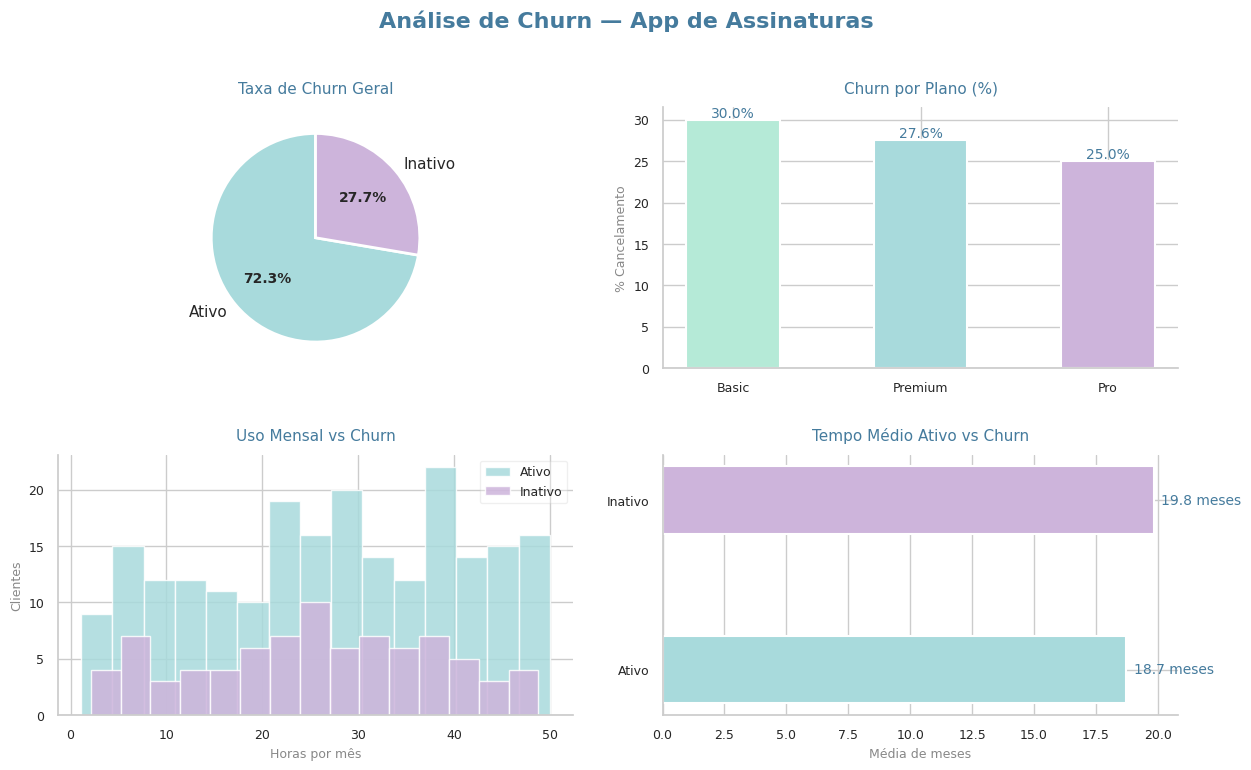

✅ Gráfico salvo!


In [10]:
cores_churn = ["#a8dadc", "#cdb4db"]
cores_plano = ["#b5ead7", "#a8dadc", "#cdb4db"]

fig, axs = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Análise de Churn — App de Assinaturas",
             fontsize=16, fontweight="bold", color="#457b9d")

# Gráfico 1 — Pizza
churn_pct = df["churn"].value_counts(normalize=True) * 100
wedges, texts, autotexts = axs[0,0].pie(
    churn_pct, labels=["Ativo", "Inativo"],
    autopct="%1.1f%%", colors=cores_churn,
    startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
for text in autotexts:
    text.set_fontsize(10)
    text.set_fontweight("bold")
axs[0,0].set_title("Taxa de Churn Geral", fontsize=11, color="#457b9d", pad=10)

# Gráfico 2 — Barras por plano
churn_plano = df.groupby("plano")["churn"].mean() * 100
bars = axs[0,1].bar(churn_plano.index, churn_plano.values,
                    color=cores_plano, edgecolor="white", linewidth=1.5, width=0.5)
for bar in bars:
    axs[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                  f"{bar.get_height():.1f}%", ha="center", fontsize=10, color="#457b9d")
axs[0,1].set_title("Churn por Plano (%)", fontsize=11, color="#457b9d", pad=10)
axs[0,1].set_ylabel("% Cancelamento", fontsize=9, color="#888")
axs[0,1].tick_params(labelsize=9)
axs[0,1].spines[["top", "right"]].set_visible(False)

# Gráfico 3 — Histograma
df[df["churn"]==0]["uso_mensal_horas"].hist(ax=axs[1,0], color="#a8dadc", alpha=0.85, label="Ativo", bins=15)
df[df["churn"]==1]["uso_mensal_horas"].hist(ax=axs[1,0], color="#cdb4db", alpha=0.85, label="Inativo", bins=15)
axs[1,0].set_title("Uso Mensal vs Churn", fontsize=11, color="#457b9d", pad=10)
axs[1,0].set_xlabel("Horas por mês", fontsize=9, color="#888")
axs[1,0].set_ylabel("Clientes", fontsize=9, color="#888")
axs[1,0].legend(fontsize=9, framealpha=0.3, edgecolor="#ccc")
axs[1,0].tick_params(labelsize=9)
axs[1,0].spines[["top", "right"]].set_visible(False)

# Gráfico 4 — Barras horizontais tempo ativo
churn_tempo = df.groupby("churn")["meses_ativo"].mean()
axs[1,1].barh(["Ativo", "Inativo"], churn_tempo.values,
              color=["#a8dadc", "#cdb4db"], edgecolor="white", linewidth=1.5, height=0.4)
for i, v in enumerate(churn_tempo.values):
    axs[1,1].text(v + 0.3, i, f"{v:.1f} meses", va="center", fontsize=10, color="#457b9d")
axs[1,1].set_title("Tempo Médio Ativo vs Churn", fontsize=11, color="#457b9d", pad=10)
axs[1,1].set_xlabel("Média de meses", fontsize=9, color="#888")
axs[1,1].tick_params(labelsize=9)
axs[1,1].spines[["top", "right"]].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig("churn_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico salvo!")

In [ ]:
from google.colab import files
files.download("churn_analysis.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🔍 Conclusões

- Aproximadamente **30% dos clientes cancelaram** a assinatura
- Clientes do plano **Basic** têm maior taxa de churn
- Clientes que **usam menos o app** tendem a cancelar mais
- Clientes **mais novos** (poucos meses ativos) cancelam mais

## 💡 Recomendações

- Criar ações de engajamento para clientes com baixo uso mensal
- Oferecer benefícios exclusivos para clientes do plano Basic
- Criar programa de onboarding para clientes nos primeiros 3 meses

## 🗄️ Consulta SQL equivalente

Caso os dados estivessem em um banco de dados, a consulta seria:

```sql
SELECT
    plano,
    COUNT(*) AS total_clientes,
    SUM(churn) AS cancelamentos,
    ROUND(AVG(churn) * 100, 1) AS taxa_churn_pct
FROM clientes
GROUP BY plano
ORDER BY taxa_churn_pct DESC;
```